# Veri Madenciliği Final Projesi — Bölüm 1: Veri Ön İşleme, Keşif ve Görselleştirme

**Ders:** MIS643 Veri Madenciliği (Lisansüstü)
**Öğrenci:** Dilber Cansu TORAMAN — 25220903022
**Problem:** Yükseköğretim öğrencilerinin dönem sonu başarı düzeyinin (Düşük / Orta / Yüksek) anket maddeleri ve ders bilgisinden tahmini — çok sınıflı sınıflandırma.

Bu defter, veri akışının ilk yarısını oluşturur: ham verinin okunması, temizlenmesi, hedef değişkenin üretilmesi, özellik mühendisliği ve keşifsel veri analizi (EDA). Defterin sonunda işlenmiş veri seti `student_data_processed.csv` olarak kaydedilir ve ikinci defterde (`model_dev`) modelleme için kullanılır.

## 1. Kütüphanelerin Yüklenmesi

Veri işleme için `pandas`/`numpy`, görselleştirme için `matplotlib`/`seaborn`, boyut indirgeme keşfi için `scikit-learn` kullanılıyor. Tekrarlanabilirlik adına grafik stili sabitleniyor.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
print("Kutuphaneler yuklendi.")

Kutuphaneler yuklendi.


## 2. Veri Setinin Okunması ve İlk İnceleme

Veri seti UCI *Higher Education Students Performance Evaluation* veri kümesidir. Dosya noktalı virgül (`;`) ile ayrılmıştır. Sütun adlarındaki olası boşluklar temizlenir. Veri 145 öğrenci gözlemi ve 33 sütundan oluşur: öğrenci kimliği, 1–30 arası anket maddeleri, ders kimliği (`COURSE ID`) ve ham not (`GRADE`).

In [2]:
df = pd.read_csv("DATA.csv", sep=";")
df.columns = df.columns.str.strip()

print("Veri seti boyutu:", df.shape)
print("Sutunlar:", df.columns.tolist())
display(df.head())

Veri seti boyutu: (145, 33)
Sutunlar: ['STUDENT ID', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', 'COURSE ID', 'GRADE']


,STUDENT ID,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,COURSE ID,GRADE
0,STUDENT1,2,2,3,3,1,2,2,1,1,1,1,2,3,1,2,5,3,2,2,1,1,1,1,1,3,2,1,2,1,1,1,1
1,STUDENT2,2,2,3,3,1,2,2,1,1,1,2,3,2,1,2,1,2,2,2,1,1,1,1,1,3,2,3,2,2,3,1,1
2,STUDENT3,2,2,2,3,2,2,2,2,4,2,2,2,2,1,2,1,2,1,2,1,1,1,1,1,2,2,1,1,2,2,1,1
3,STUDENT4,1,1,1,3,1,2,1,2,1,2,1,2,5,1,2,1,3,1,2,1,1,1,1,2,3,2,2,1,3,2,1,1
4,STUDENT5,2,2,1,3,2,2,1,3,1,4,3,3,2,1,2,4,2,1,1,1,1,1,2,1,2,2,2,1,2,2,1,1


## 3. Veri Yapısı, Eksik ve Yinelenen Kayıt Kontrolü

Veri tiplerini, eksik değerleri ve yinelenen kayıtları kontrol ediyoruz. Bu üç kontrol, temizlik kararlarının gerekçesini oluşturur.

In [3]:
print("=== Veri tipleri ===")
df.info()

print("\n=== Eksik deger sayilari (toplam) ===")
print("Toplam eksik hucre:", int(df.isnull().sum().sum()))

print("\n=== Yinelenen kayit sayisi ===")
print("Yinelenen satir:", int(df.duplicated().sum()))

=== Veri tipleri ===
<class 'pandas.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   STUDENT ID  145 non-null    str  
 1   1           145 non-null    int64
 2   2           145 non-null    int64
 3   3           145 non-null    int64
 4   4           145 non-null    int64
 5   5           145 non-null    int64
 6   6           145 non-null    int64
 7   7           145 non-null    int64
 8   8           145 non-null    int64
 9   9           145 non-null    int64
 10  10          145 non-null    int64
 11  11          145 non-null    int64
 12  12          145 non-null    int64
 13  13          145 non-null    int64
 14  14          145 non-null    int64
 15  15          145 non-null    int64
 16  16          145 non-null    int64
 17  17          145 non-null    int64
 18  18          145 non-null    int64
 19  19          145 non-null    int64
 20  20          145 non-nu

### 3.1 Temizlik kararları (gerekçeli)

- **Eksik değer:** Veri setinde eksik hücre bulunmamaktadır; bu nedenle değer atama (imputation) veya satır silme gerekmez.
- **Yinelenen kayıt:** `drop_duplicates()` koruyucu amaçla çağrılır; veri zaten tekrarsız olduğundan boyut değişmez.
- **`STUDENT ID`:** Her gözlemi benzersiz biçimde etiketleyen kimlik alanıdır, tahmin için açıklayıcı bilgi taşımaz ve modele bırakılırsa gürültü/aşırı uyum riski oluşturur; bu yüzden çıkarılır.
- Tüm anket maddeleri 1–5 Likert ölçeğinde olduğu için tip dönüşümü gerekmez.

In [4]:
before = df.shape[0]
df = df.drop_duplicates().copy()
print("drop_duplicates sonrasi kaldirilan satir:", before - df.shape[0])

if "STUDENT ID" in df.columns:
    df = df.drop(columns=["STUDENT ID"])

print("Temizlik sonrasi boyut:", df.shape)
display(df.head())

drop_duplicates sonrasi kaldirilan satir: 0
Temizlik sonrasi boyut: (145, 32)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,COURSE ID,GRADE
0,2,2,3,3,1,2,2,1,1,1,1,2,3,1,2,5,3,2,2,1,1,1,1,1,3,2,1,2,1,1,1,1
1,2,2,3,3,1,2,2,1,1,1,2,3,2,1,2,1,2,2,2,1,1,1,1,1,3,2,3,2,2,3,1,1
2,2,2,2,3,2,2,2,2,4,2,2,2,2,1,2,1,2,1,2,1,1,1,1,1,2,2,1,1,2,2,1,1
3,1,1,1,3,1,2,1,2,1,2,1,2,5,1,2,1,3,1,2,1,1,1,1,2,3,2,2,1,3,2,1,1
4,2,2,1,3,2,2,1,3,1,4,3,3,2,1,2,4,2,1,1,1,1,1,2,1,2,2,2,1,2,2,1,1


## 4. Hedef Değişkenin Oluşturulması (Başarı Düzeyi)

Ham `GRADE` değişkeni 0–7 arası **sekiz** seviyelidir. Bu kadar ince ayrım, 145 gözlemli küçük bir veri için seyrek sınıflara ve düşük genellemeye yol açar. Bu nedenle eğitimsel olarak yorumlanabilir **üç başarı düzeyine** indirgenir:

| GRADE | Başarı düzeyi |
|---|---|
| 0–2 | Düşük (Low) |
| 3–5 | Orta (Medium) |
| 6–7 | Yüksek (High) |

Bu, dengeli ve yorumlanabilir bir çok sınıflı sınıflandırma problemi tanımlar.

In [5]:
def map_grade_to_level(grade):
    if grade <= 2:
        return "Dusuk"
    elif grade <= 5:
        return "Orta"
    else:
        return "Yuksek"

df["basari_duzeyi"] = df["GRADE"].apply(map_grade_to_level)

dist = df["basari_duzeyi"].value_counts().reindex(["Dusuk", "Orta", "Yuksek"])
print("Sinif dagilimi:")
print(dist.to_string())
print("\nSinif oranlari (%):")
print((dist / dist.sum() * 100).round(1).to_string())

Sinif dagilimi:
basari_duzeyi
Dusuk     67
Orta      48
Yuksek    30

Sinif oranlari (%):
basari_duzeyi
Dusuk     46.2
Orta      33.1
Yuksek    20.7


**Gözlem:** Düşük=67, Orta=48, Yüksek=30. Sınıflar tam dengeli değildir; Yüksek başarı sınıfı en az gözlemi içerir. Bu nedenle modelleme aşamasında yalnızca *accuracy* değil, sınıf-duyarlı *precision/recall/F1* metrikleri de raporlanacaktır.

## 5. Özellik Mühendisliği

Tek tek 30 maddeye ek olarak, öğrencinin **genel yanıt örüntüsünü** özetleyen üç türetilmiş değişken üretilir. Küçük veri setlerinde bu tür toplulaştırılmış sinyaller, özellikle ağaç tabanlı modellerde gürültüyü azaltıp ayırt ediciliği artırabilir.

- `soru_toplam`: 30 maddenin toplamı (genel yanıt yoğunluğu)
- `soru_ortalama`: ortalama yanıt seviyesi
- `soru_std`: maddeler arası değişkenlik (tutarlılık göstergesi)

In [6]:
question_cols = [str(i) for i in range(1, 31)]

df["soru_toplam"] = df[question_cols].sum(axis=1)
df["soru_ortalama"] = df[question_cols].mean(axis=1)
df["soru_std"] = df[question_cols].std(axis=1)

display(df[["GRADE", "basari_duzeyi", "soru_toplam", "soru_ortalama", "soru_std"]].head())
print("\nTuretilmis degiskenlerin ozeti:")
display(df[["soru_toplam", "soru_ortalama", "soru_std"]].describe().round(2))


Turetilmis degiskenlerin ozeti:


,GRADE,basari_duzeyi,soru_toplam,soru_ortalama,soru_std
0,1,Dusuk,54,1.800000,0.961321
1,1,Dusuk,55,1.833333,0.746640
2,1,Dusuk,53,1.766667,0.678911
3,1,Dusuk,52,1.733333,0.944433
4,1,Dusuk,57,1.900000,0.884736


,soru_toplam,soru_ortalama,soru_std
count,145.00,145.00,145.00
mean,59.59,1.99,1.01
std,4.71,0.16,0.15
min,49.00,1.63,0.50
25%,56.00,1.87,0.91
50%,59.00,1.97,0.99
75%,63.00,2.10,1.12
max,73.00,2.43,1.36


## 6. Keşifsel Veri Analizi ve Görselleştirme

Aşağıdaki görseller hedef değişkenin yapısını, türetilmiş değişkenlerin dağılımını, maddeler arası korelasyonu, ders bağlamını ve aykırı/ayırt edici örüntüleri inceler.

### 6.1 Ham not ve dönüştürülmüş başarı düzeyi dağılımı

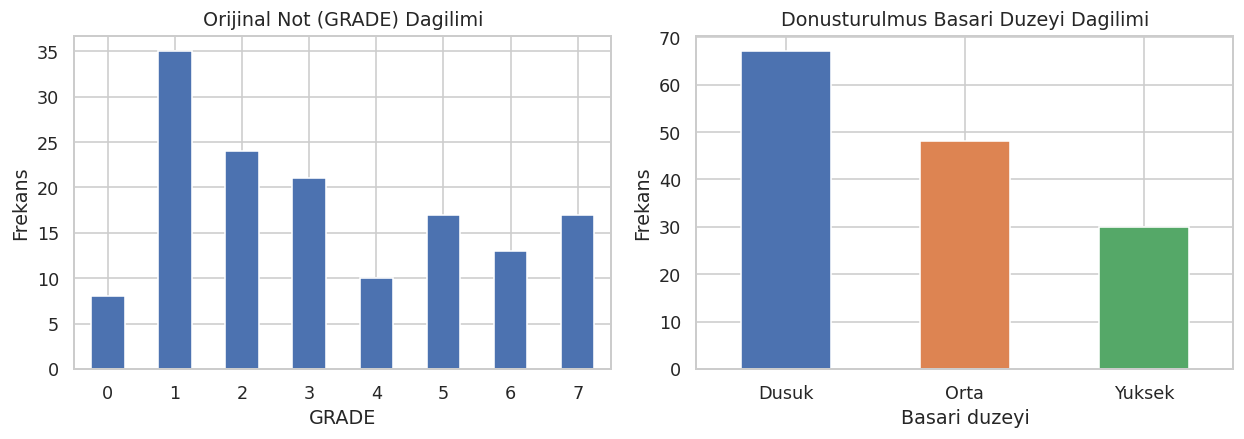

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["GRADE"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Orijinal Not (GRADE) Dagilimi")
axes[0].set_xlabel("GRADE"); axes[0].set_ylabel("Frekans")
axes[0].tick_params(axis="x", rotation=0)

order = ["Dusuk", "Orta", "Yuksek"]
colors = ["#4C72B0", "#DD8452", "#55A868"]
df["basari_duzeyi"].value_counts().reindex(order).plot(kind="bar", ax=axes[1], color=colors)
axes[1].set_title("Donusturulmus Basari Duzeyi Dagilimi")
axes[1].set_xlabel("Basari duzeyi"); axes[1].set_ylabel("Frekans")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

### 6.2 Türetilmiş değişkenlerin dağılımı (histogram)

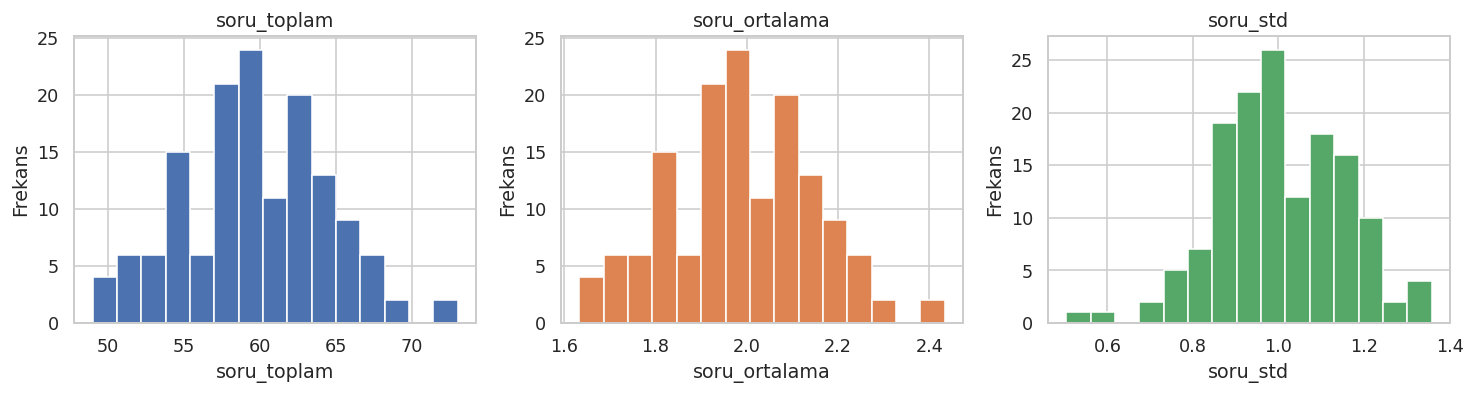

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col, c in zip(axes, ["soru_toplam", "soru_ortalama", "soru_std"], ["#4C72B0", "#DD8452", "#55A868"]):
    ax.hist(df[col], bins=15, color=c, edgecolor="white")
    ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel("Frekans")
plt.tight_layout(); plt.show()

### 6.3 Anket maddeleri arası korelasyon ısı haritası

30 maddenin Pearson korelasyon matrisi. Yüksek korelasyon kümeleri, maddelerin birbiriyle ilişkili olduğunu ve toplulaştırılmış özet değişkenlerin (Bölüm 5) neden anlamlı olduğunu gösterir.

Ortalama mutlak korelasyon (kosegen haric): 0.100


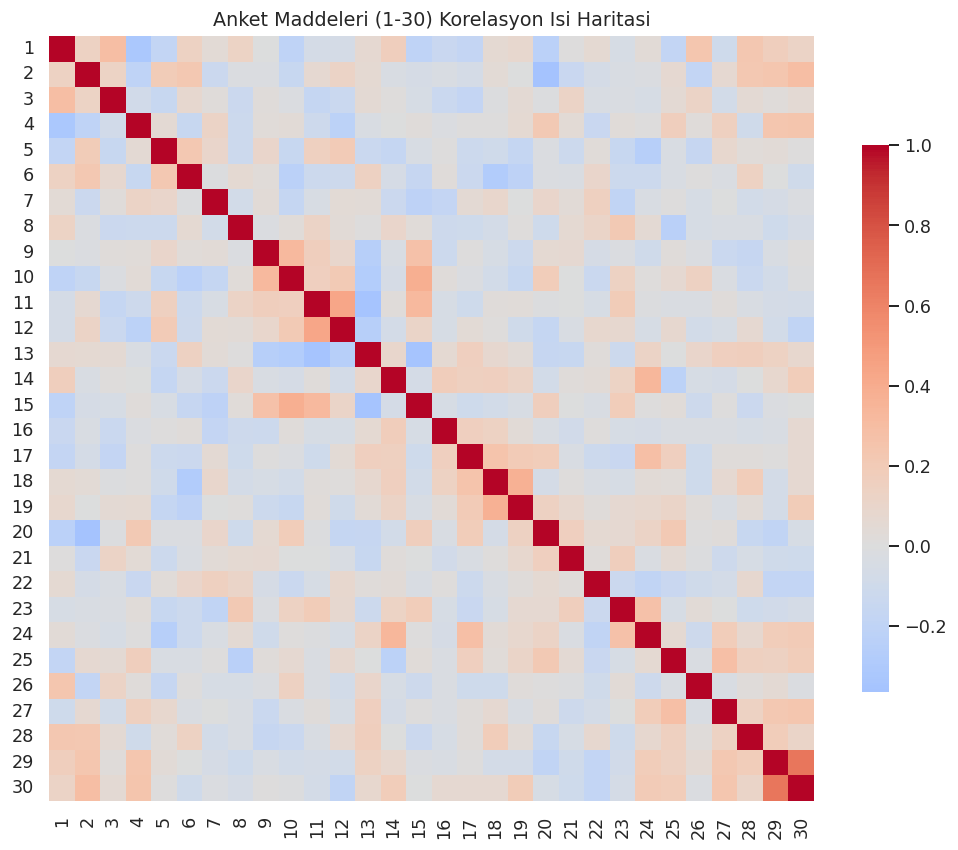

In [9]:
corr = df[question_cols].astype(float).corr()
plt.figure(figsize=(9, 7.5))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.7}, xticklabels=True, yticklabels=True)
plt.title("Anket Maddeleri (1-30) Korelasyon Isi Haritasi")
plt.tight_layout(); plt.show()

print("Ortalama mutlak korelasyon (kosegen haric): %.3f" %
      corr.where(~np.eye(len(corr), dtype=bool)).abs().stack().mean())

### 6.4 Başarı düzeyine göre özet değişkenler (boxplot)

Boxplot'lar, türetilmiş değişkenlerin başarı düzeyleri arasında ayrışıp ayrışmadığını ve aykırı değerleri görselleştirir.

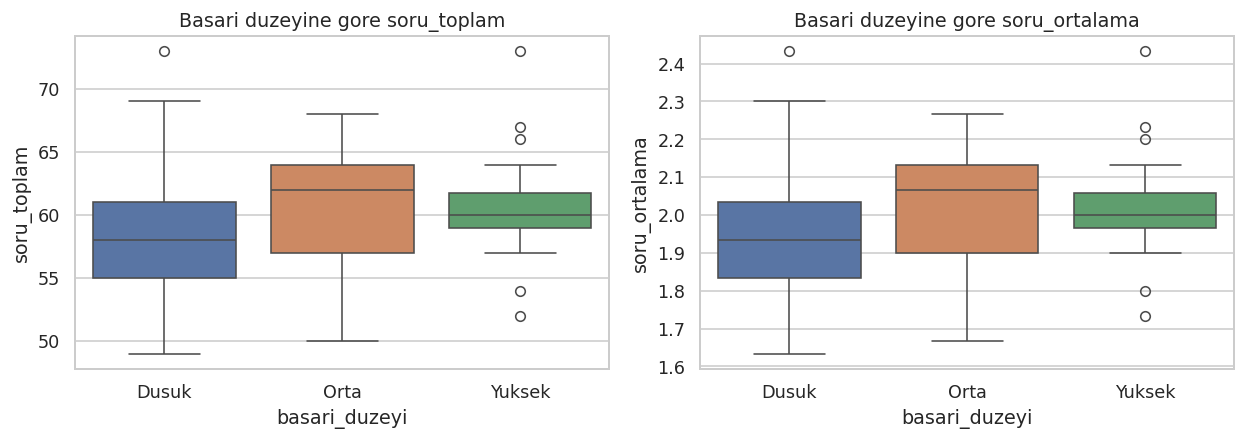

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x="basari_duzeyi", y="soru_toplam", order=order, ax=axes[0], palette=colors)
axes[0].set_title("Basari duzeyine gore soru_toplam")
sns.boxplot(data=df, x="basari_duzeyi", y="soru_ortalama", order=order, ax=axes[1], palette=colors)
axes[1].set_title("Basari duzeyine gore soru_ortalama")
plt.tight_layout(); plt.show()

### 6.5 Ders kimliğine göre başarı düzeyi

Bazı derslerin belirli başarı düzeyleriyle ilişkili olup olmadığını gösterir (ders bağlamı sinyali).

basari_duzeyi,Dusuk,Orta,Yuksek
COURSE ID,,,
1,41,25,0
2,1,1,0
3,0,2,6
4,0,3,1
5,0,4,3
6,0,1,7
7,0,2,13
8,14,0,0
9,11,10,0


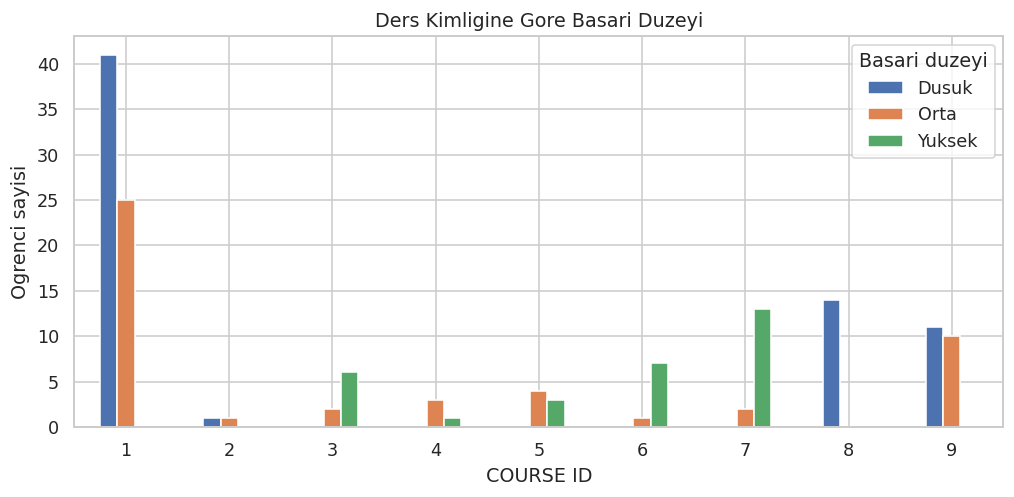

In [11]:
course_perf = pd.crosstab(df["COURSE ID"], df["basari_duzeyi"]).reindex(columns=order)
display(course_perf)
course_perf.plot(kind="bar", figsize=(9, 4.5), color=colors)
plt.title("Ders Kimligine Gore Basari Duzeyi")
plt.xlabel("COURSE ID"); plt.ylabel("Ogrenci sayisi")
plt.xticks(rotation=0); plt.legend(title="Basari duzeyi")
plt.tight_layout(); plt.show()

### 6.6 Boyut indirgeme keşfi (PCA)

30 standartlaştırılmış madde üzerinde PCA, açıklanan varyansın bileşen sayısıyla nasıl biriktiğini gösterir. Bu, ana modelleme hattının zorunlu adımı değil; verinin içsel boyutluluğunu anlamaya yönelik keşifsel bir analizdir.

Ilk 10 bilesenin acikladigi toplam varyans: 61.01%
%80 varyans icin gereken bilesen sayisi: 17


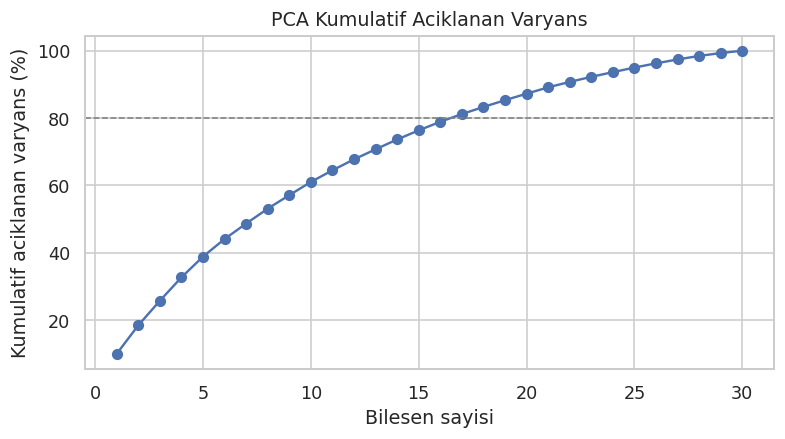

In [12]:
X_items = StandardScaler().fit_transform(df[question_cols].astype(float))
pca = PCA().fit(X_items)
cum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum) + 1), cum * 100, marker="o", color="#4C72B0")
plt.axhline(80, color="grey", linestyle="--", linewidth=1)
plt.title("PCA Kumulatif Aciklanan Varyans")
plt.xlabel("Bilesen sayisi"); plt.ylabel("Kumulatif aciklanan varyans (%)")
plt.tight_layout(); plt.show()

print("Ilk 10 bilesenin acikladigi toplam varyans: %.2f%%" % (cum[9] * 100))
print("%%80 varyans icin gereken bilesen sayisi: %d" % (int(np.argmax(cum >= 0.80) + 1)))

### 6.7 PCA bileşen uzayında saçılım (sınıf ayrışması ve anomaliler)

İlk iki PCA bileşeni üzerinde gözlemleri bir saçılım (dağılım) grafiğiyle göstermek, başarı düzeylerinin özellik uzayında ne ölçüde ayrıştığını ve olası aykırı (anomali) gözlemleri görsel olarak ortaya koyar. Tam ayrışmamış, iç içe geçmiş bulutlar sınıflandırmanın neden kolay olmadığını da açıklar.

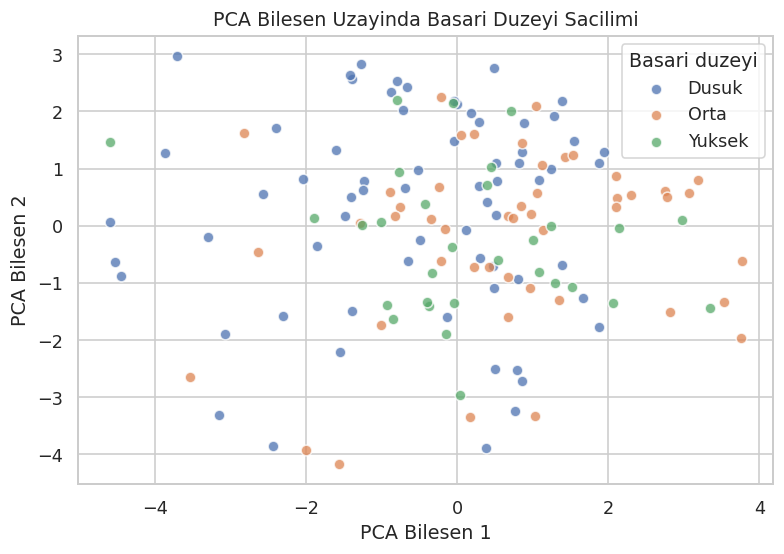

In [13]:
pca2 = PCA(n_components=2).fit_transform(X_items)
plt.figure(figsize=(7, 5))
for lvl, col in zip(order, colors):
    m = (df["basari_duzeyi"] == lvl).values
    plt.scatter(pca2[m, 0], pca2[m, 1], c=col, label=lvl,
                alpha=0.75, edgecolor="white", s=45)
plt.xlabel("PCA Bilesen 1"); plt.ylabel("PCA Bilesen 2")
plt.title("PCA Bilesen Uzayinda Basari Duzeyi Sacilimi")
plt.legend(title="Basari duzeyi")
plt.tight_layout(); plt.show()

## 7. İşlenmiş Verinin Kaydedilmesi

Temizlenmiş, hedef değişkeni ve türetilmiş özellikleri içeren veri seti diske yazılır; ikinci defter (`model_dev`) bu dosyayı bağımsız olarak yükleyerek modelleme yapar.

In [14]:
out_cols = question_cols + ["COURSE ID", "soru_toplam", "soru_ortalama", "soru_std",
                            "GRADE", "basari_duzeyi"]
df[out_cols].to_csv("student_data_processed.csv", index=False)
print("Kaydedildi: student_data_processed.csv  ->", df[out_cols].shape)
display(df[out_cols].head())

Kaydedildi: student_data_processed.csv  -> (145, 36)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,COURSE ID,soru_toplam,soru_ortalama,soru_std,GRADE,basari_duzeyi
0,2,2,3,3,1,2,2,1,1,1,1,2,3,1,2,5,3,2,2,1,1,1,1,1,3,2,1,2,1,1,1,54,1.800000,0.961321,1,Dusuk
1,2,2,3,3,1,2,2,1,1,1,2,3,2,1,2,1,2,2,2,1,1,1,1,1,3,2,3,2,2,3,1,55,1.833333,0.746640,1,Dusuk
2,2,2,2,3,2,2,2,2,4,2,2,2,2,1,2,1,2,1,2,1,1,1,1,1,2,2,1,1,2,2,1,53,1.766667,0.678911,1,Dusuk
3,1,1,1,3,1,2,1,2,1,2,1,2,5,1,2,1,3,1,2,1,1,1,1,2,3,2,2,1,3,2,1,52,1.733333,0.944433,1,Dusuk
4,2,2,1,3,2,2,1,3,1,4,3,3,2,1,2,4,2,1,1,1,1,1,2,1,2,2,2,1,2,2,1,57,1.900000,0.884736,1,Dusuk


## 8. Bölüm 1 Özeti

- Veri **eksiksiz ve tekrarsız**; kimlik alanı çıkarıldı.
- 8 seviyeli ham not, yorumlanabilir **3 başarı düzeyine** dönüştürüldü (Düşük 67 / Orta 48 / Yüksek 30).
- Üç **özet özellik** üretildi (`soru_toplam`, `soru_ortalama`, `soru_std`).
- EDA, maddeler arası korelasyon kümelerini, ders bağlamı sinyalini ve özet değişkenlerin başarı düzeyleri arasında ayrışma eğilimini ortaya koydu.
- PCA, ilk 10 bileşenin varyansın ~%61'ini açıkladığını gösterdi; ana hatta zorunlu değil.

İşlenmiş veri `model_dev` defterinde modellenecektir.